Cluster number: [0]


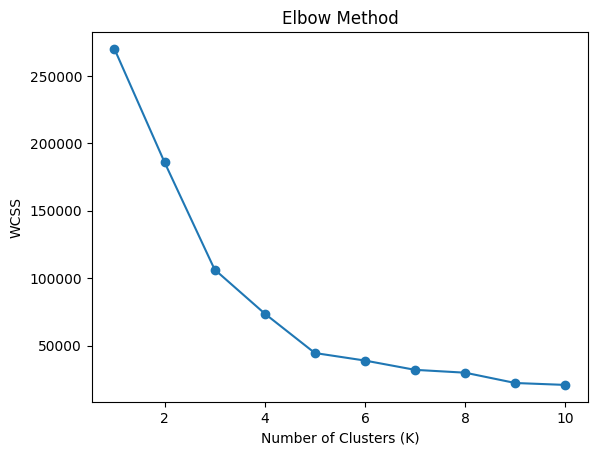

Optimal K: 5
Cluster number: 3


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from kneed import KneeLocator

data = pd.read_csv('Mall_Customers.csv')
data.head()
X = data.iloc[:, [3, 4]].values

kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X)

# User Input
new_customer = np.array([[30, 40]])   # Income=30, Spending=40
# Predict cluster
cluster = kmeans.predict(new_customer)
print("Cluster number:", cluster)

# elbow method
wcss = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

knee = KneeLocator(K, wcss, curve='convex', direction='decreasing')
optimal_k = knee.elbow
print("Optimal K:", optimal_k)

kmeans = KMeans(n_clusters=optimal_k, random_state=0)
kmeans.fit(X)

# User Input
new_customer = np.array([[30, 40]])   # Income=30, Spending=40
# Predict cluster
cluster = kmeans.predict(new_customer)
print("Cluster number:", cluster[0])

Cluster number (with K=2): 0


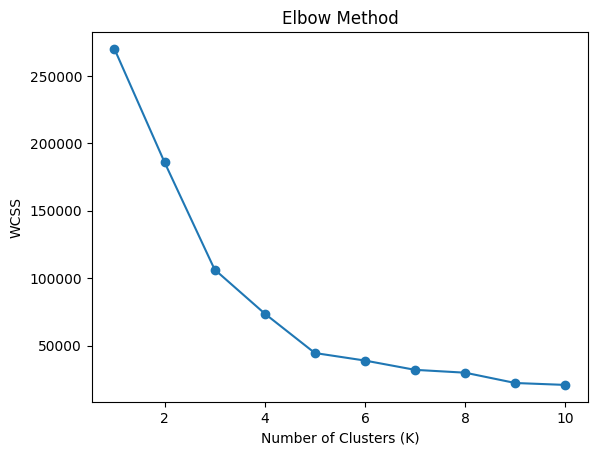

Optimal K: 5
Cluster number (with optimal K): 3


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from kneed import KneeLocator

# Load dataset
data = pd.read_csv('Mall_Customers.csv')
X = data.iloc[:, [3, 4]].values   # Income vs Spending

# Initial clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X)

# User Input
new_customer = np.array([[30, 40]])   # Income=30, Spending=40
cluster = kmeans.predict(new_customer)
print("Cluster number (with K=2):", cluster[0])

# Elbow method
wcss = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

# Find optimal K
knee = KneeLocator(K, wcss, curve='convex', direction='decreasing')
optimal_k = knee.elbow
print("Optimal K:", optimal_k)

# Fit KMeans with optimal K
kmeans = KMeans(n_clusters=optimal_k, random_state=0)
kmeans.fit(X)

# Predict cluster for new customer
new_customer = np.array([[30, 40]])
cluster = kmeans.predict(new_customer)
print("Cluster number (with optimal K):", cluster[0])